## Part 3: Regime Detection using Hidden Markov Model

A 3-state Hidden Markov Model (Gaussian HMM) was used to classify market regimes
based on options-derived features and spot returns.

Input features included Average IV, IV Spread, PCR (OI-based), ATM Greeks,
Futures Basis, and Spot Returns.

The model was trained on the first 70% of the data.
Regimes were mapped to market direction using mean spot returns per state:
- +1: Uptrend
- 0: Sideways
- -1: Downtrend

In [60]:
import pandas as pd
import numpy as np
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler

In [61]:
#Load Feature Dataset
df = pd.read_csv(
    "../data/final/nifty_features_5min.csv",
    low_memory=False
)

df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

In [62]:
hmm_features = [
    "avg_iv",
    "iv_spread",
    "pcr_oi",
    "delta_ce",
    "gamma_ce",
    "vega_ce",
    "futures_basis",
    "spot_returns"
]

# 1. Check column existence
print("Missing columns:",
      set(hmm_features) - set(df.columns))

# 2. Check non-null counts
print("\nNon-null counts:")
print(df[hmm_features].notna().sum())

# 3. Check how many rows have ALL features present
valid_rows = df[hmm_features].notna().all(axis=1)
print("\nRows with all HMM features present:", valid_rows.sum())


Missing columns: set()

Non-null counts:
avg_iv           225575
iv_spread        225575
pcr_oi           289973
delta_ce         225575
gamma_ce         225575
vega_ce          225575
futures_basis    289973
spot_returns     289972
dtype: int64

Rows with all HMM features present: 225574


In [63]:
hmm_features = [
    "iv_ce",          
    "pcr_oi",
    "delta_ce",
    "gamma_ce",
    "vega_ce",
    "futures_basis",
    "spot_returns"
]

In [64]:
df[hmm_features].notna().sum()

iv_ce            225575
pcr_oi           289973
delta_ce         225575
gamma_ce         225575
vega_ce          225575
futures_basis    289973
spot_returns     289972
dtype: int64

In [65]:
X = df[hmm_features].dropna()
print("HMM samples:", len(X))

HMM samples: 225574


In [66]:
# 70% train split
split_idx = int(len(X) * 0.7)

X_train = X[:split_idx]
X_full  = X

In [71]:
from hmmlearn.hmm import GaussianHMM

hmm = GaussianHMM(
    n_components=3,
    covariance_type="diag",
    n_iter=500,
    tol=1e-3,
    random_state=42
)

hmm.fit(X)

Model is not converging.  Current: -1689390.9257843692 is not greater than -1689390.8086255798. Delta is -0.1171587894205004


GaussianHMM(n_components=3, n_iter=500, random_state=42, tol=0.001)

In [72]:
print("Converged:", hmm.monitor_.converged)
print("Iterations:", hmm.monitor_.iter)
print("Final log likelihood:", hmm.monitor_.history[-1])

Converged: True
Iterations: 56
Final log likelihood: -1689390.9257843692


In [73]:
states = hmm.predict(X)
np.unique(states)

array([0, 1, 2], dtype=int64)

In [74]:
hidden_states = hmm.predict(X_full)

df_hmm = df.loc[X.index].copy()
df_hmm["hmm_state"] = hidden_states

In [79]:
state_returns = (
    df_hmm.groupby("hmm_state")["spot_returns"]
    .mean()
    .sort_values()
)

state_returns

hmm_state
2   -0.044033
0    0.119116
1    0.335135
Name: spot_returns, dtype: float64

Regime Labeling
HMM latent states were mapped to market regimes based on mean spot returns per state.
The state with the lowest average return was labeled as Downtrend (−1), the highest as Uptrend (+1), and the remaining state as Sideways (0).

In [80]:
sorted_states = state_returns.index.tolist()

state_map = {
    sorted_states[0]: -1,  # Lowest return → Downtrend
    sorted_states[1]:  0,  # Middle → Sideways
    sorted_states[2]:  1   # Highest → Uptrend
}

state_map

{2: -1, 0: 0, 1: 1}

In [81]:
df_hmm["market_regime"].value_counts()

market_regime
 1    115078
 0     89062
-1     21434
Name: count, dtype: int64

In [82]:
df["market_regime"] = np.nan
df.loc[df_hmm.index, "market_regime"] = df_hmm["market_regime"]

df.to_csv(
    "../data/final/nifty_features_with_regime_5min.csv",
    index=False
)

## Task 3.2: Regime Visualization

Market regimes identified using HMM were analyzed through multiple visualizations.
A price chart with regime overlay illustrates regime alignment with market trends.
A transition matrix highlights regime persistence and switching behavior.
Regime-wise distributions of IV and Greeks provide insight into option market
characteristics under different regimes. A duration histogram shows how long
each regime typically persists.


In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

In [84]:
df = pd.read_csv("../data/final/nifty_features_with_regime_5min.csv", low_memory=False)
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

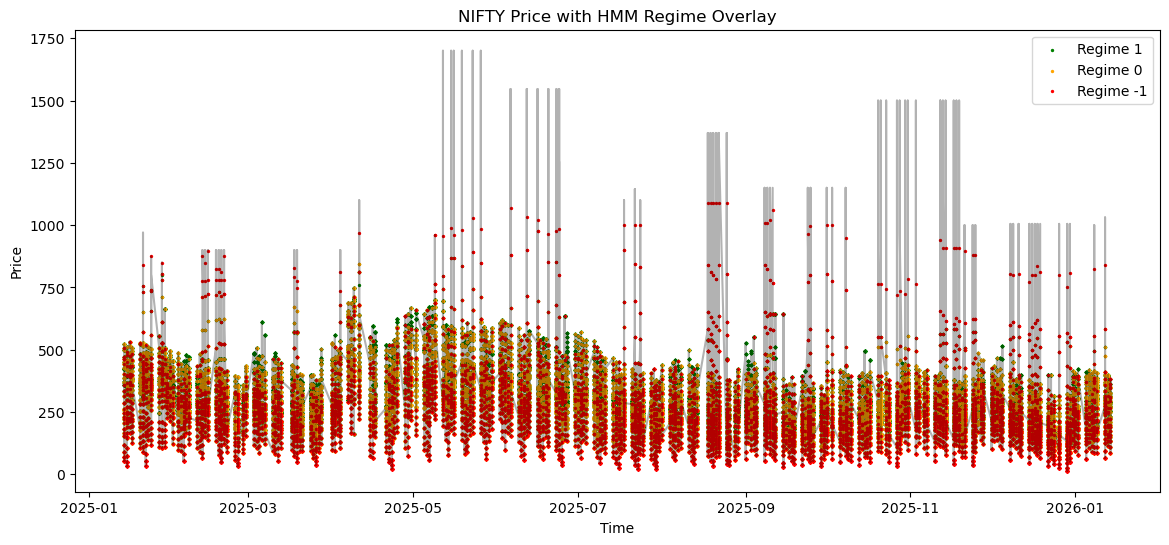

In [85]:
plt.figure(figsize=(14,6))

colors = {1: "green", 0: "orange", -1: "red"}

for regime, color in colors.items():
    subset = df[df["market_regime"] == regime]
    plt.scatter(
        subset["timestamp"],
        subset["close"],
        s=2,
        color=color,
        label=f"Regime {regime}"
    )

plt.plot(df["timestamp"], df["close"], color="black", alpha=0.3)
plt.legend()
plt.title("NIFTY Price with HMM Regime Overlay")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()

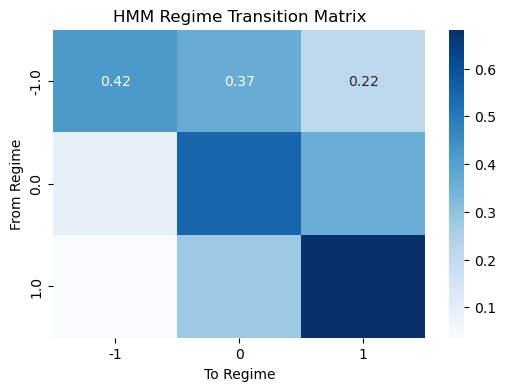

In [86]:
regime_series = df["market_regime"].dropna().astype(int)

transition_matrix = pd.crosstab(
    regime_series.shift(1),
    regime_series,
    normalize="index"
)

plt.figure(figsize=(6,4))
sns.heatmap(
    transition_matrix,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)
plt.title("HMM Regime Transition Matrix")
plt.xlabel("To Regime")
plt.ylabel("From Regime")
plt.show()

In [87]:
regime_stats = df.groupby("market_regime")[
    ["iv_ce", "delta_ce", "gamma_ce", "vega_ce"]
].mean()

regime_stats

,iv_ce,delta_ce,gamma_ce,vega_ce
market_regime,,,,
-1.0,0.593383,0.538774,0.001699,17.259455
0.0,0.281978,0.551783,0.000454,20.593768
1.0,0.105238,0.596031,0.000866,24.598098


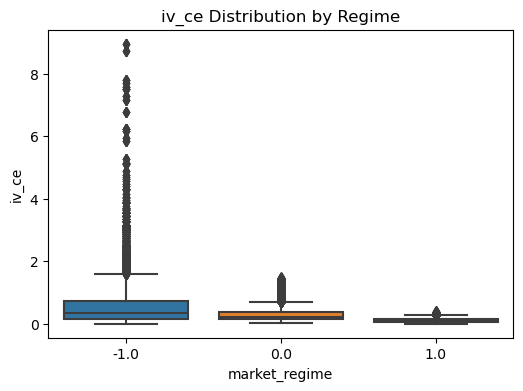

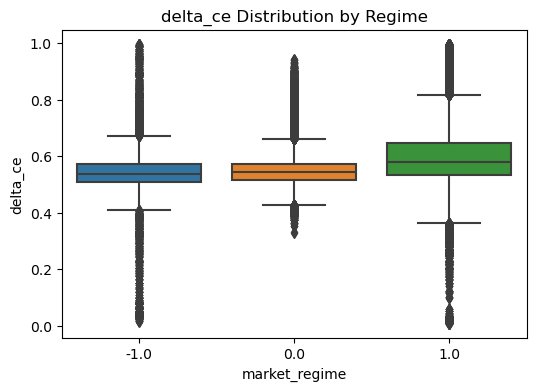

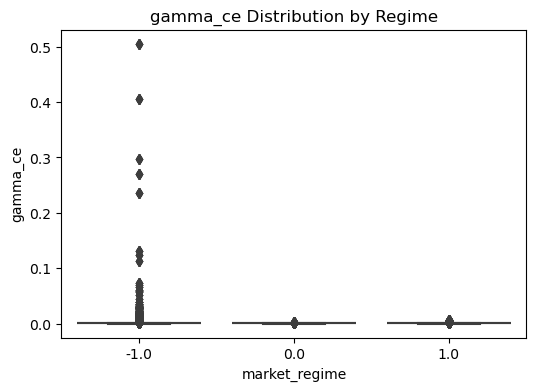

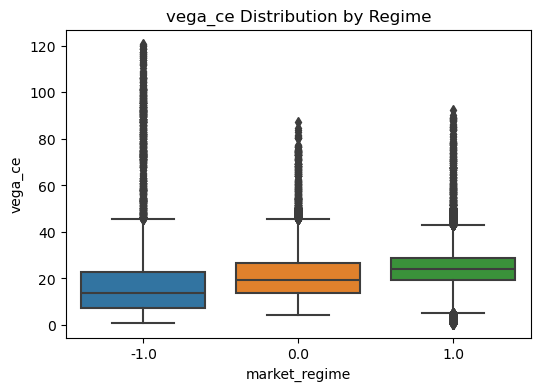

In [88]:
features = ["iv_ce", "delta_ce", "gamma_ce", "vega_ce"]

for col in features:
    plt.figure(figsize=(6,4))
    sns.boxplot(
        x="market_regime",
        y=col,
        data=df
    )
    plt.title(f"{col} Distribution by Regime")
    plt.show()

C:\Users\besan\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


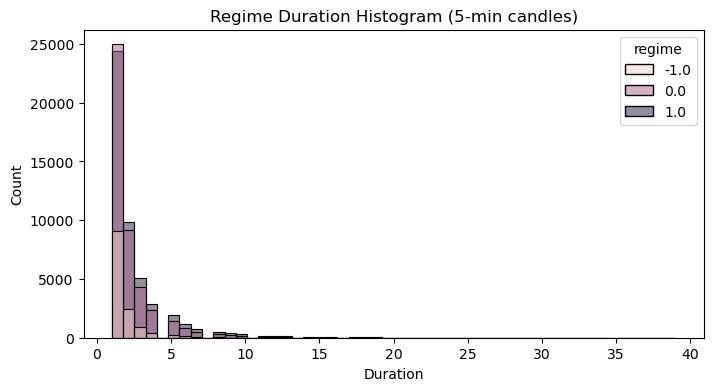

In [89]:
# Compute regime durations
regime_changes = df["market_regime"] != df["market_regime"].shift(1)
regime_blocks = regime_changes.cumsum()

durations = (
    df.groupby(regime_blocks)
    .agg(
        regime=("market_regime", "first"),
        duration=("market_regime", "size")
    )
)

plt.figure(figsize=(8,4))
sns.histplot(
    data=durations,
    x="duration",
    hue="regime",
    bins=50,
    kde=False
)
plt.title("Regime Duration Histogram (5-min candles)")
plt.xlabel("Duration")
plt.show()

In [90]:
df[[
    "avg_iv",
    "iv_spread",
    "pcr_oi",
    "pcr_volume",
    "delta_ce", "delta_pe",
    "gamma_ce", "gamma_pe",
    "vega_ce", "vega_pe",
    "futures_basis"
]].isna().mean().sort_values()


pcr_oi           0.000000
delta_pe         0.000000
gamma_pe         0.000000
vega_pe          0.000000
futures_basis    0.000000
pcr_volume       0.060375
avg_iv           0.222083
iv_spread        0.222083
delta_ce         0.222083
gamma_ce         0.222083
vega_ce          0.222083
dtype: float64